In [ ]:
import

In [1]:
class HashTable:
    def __init__(self, size=10):
        """Initialize the hash table with a fixed size."""
        self.size = size
        self.table = [[] for _ in range(size)]  # Array of empty lists for chaining

    def _hash(self, key):
        """Hash function using the division method."""
        return hash(key) % self.size

    def insert(self, key, value):
        """Insert a key-value pair into the hash table."""
        index = self._hash(key)
        # Check if the key already exists and update its value
        for pair in self.table[index]:
            if pair[0] == key:
                pair[1] = value
                return
        # If the key does not exist, append the new key-value pair
        self.table[index].append([key, value])

    def search(self, key):
        """Search for a value associated with a key."""
        index = self._hash(key)
        for pair in self.table[index]:
            if pair[0] == key:
                return pair[1]
        return None  # Key not found

    def delete(self, key):
        """Remove a key-value pair from the hash table."""
        index = self._hash(key)
        for i, pair in enumerate(self.table[index]):
            if pair[0] == key:
                del self.table[index][i]
                return True
        return False  # Key not found

    def __str__(self):
        """String representation of the hash table for debugging."""
        return str(self.table)


# Example usage
if __name__ == "__main__":
    ht = HashTable(size=5)
    ht.insert("apple", 10)
    ht.insert("banana", 20)
    ht.insert("orange", 30)
    print("Hash Table:", ht)

    print("Search 'apple':", ht.search("apple"))
    print("Search 'grape':", ht.search("grape"))

    ht.delete("banana")
    print("After deleting 'banana':", ht)

Hash Table: [[['apple', 10], ['orange', 30]], [], [], [['banana', 20]], []]
Search 'apple': 10
Search 'grape': None
After deleting 'banana': [[['apple', 10], ['orange', 30]], [], [], [], []]


Analyzing Load Factor vs. Lookup Time...


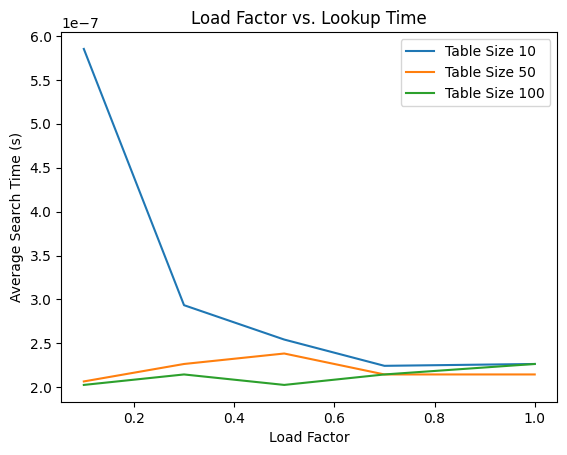

Analyzing Key Distributions...


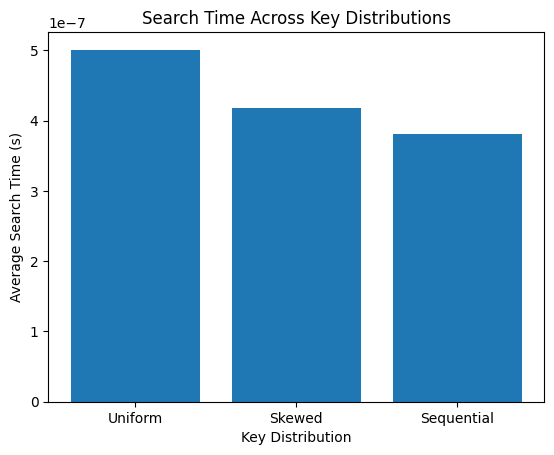

Analyzing Memory Overhead...
Average Chain Length: 0.7
Max Chain Length: 3


In [2]:
import time
import random
import matplotlib.pyplot as plt

def measure_search_time(hash_table, keys, search_keys):
    """Measure average search time for a list of keys."""
    start_time = time.time()
    for key in search_keys:
        hash_table.search(key)
    end_time = time.time()
    return (end_time - start_time) / len(search_keys)

def analyze_load_factor_vs_lookup_time():
    """Analyze load factor vs. lookup time for different table sizes."""
    table_sizes = [10, 50, 100]
    load_factors = [0.1, 0.3, 0.5, 0.7, 1.0]
    results = {size: [] for size in table_sizes}

    for size in table_sizes:
        for load_factor in load_factors:
            num_keys = int(size * load_factor)
            hash_table = HashTable(size=size)
            keys = [f"key{i}" for i in range(num_keys)]
            for key in keys:
                hash_table.insert(key, random.randint(1, 100))
            
            # Measure search time for successful and unsuccessful searches
            search_keys = random.sample(keys, min(10, len(keys))) + ["nonexistent"] * 10
            avg_time = measure_search_time(hash_table, keys, search_keys)
            results[size].append(avg_time)

    # Plot results
    for size, times in results.items():
        plt.plot(load_factors, times, label=f"Table Size {size}")
    plt.xlabel("Load Factor")
    plt.ylabel("Average Search Time (s)")
    plt.title("Load Factor vs. Lookup Time")
    plt.legend()
    plt.show()

def analyze_key_distributions():
    """Compare search time across different key distributions."""
    table_size = 50
    load_factor = 0.7
    num_keys = int(table_size * load_factor)

    # Uniform distribution
    uniform_keys = [f"key{i}" for i in range(num_keys)]
    # Skewed distribution
    skewed_keys = [f"key{random.randint(0, 10)}" for _ in range(num_keys)]
    # Sequential keys
    sequential_keys = [f"key{i}" for i in range(num_keys)]

    distributions = {
        "Uniform": uniform_keys,
        "Skewed": skewed_keys,
        "Sequential": sequential_keys,
    }

    results = {}
    for dist_name, keys in distributions.items():
        hash_table = HashTable(size=table_size)
        for key in keys:
            hash_table.insert(key, random.randint(1, 100))
        search_keys = random.sample(keys, min(10, len(keys))) + ["nonexistent"] * 10
        avg_time = measure_search_time(hash_table, keys, search_keys)
        results[dist_name] = avg_time

    # Plot results
    plt.bar(results.keys(), results.values())
    plt.xlabel("Key Distribution")
    plt.ylabel("Average Search Time (s)")
    plt.title("Search Time Across Key Distributions")
    plt.show()

def analyze_memory_overhead():
    """Analyze memory overhead for chaining."""
    table_size = 50
    load_factor = 0.7
    num_keys = int(table_size * load_factor)

    hash_table = HashTable(size=table_size)
    keys = [f"key{i}" for i in range(num_keys)]
    for key in keys:
        hash_table.insert(key, random.randint(1, 100))

    chain_lengths = [len(slot) for slot in hash_table.table]
    avg_chain_length = sum(chain_lengths) / len(chain_lengths)
    max_chain_length = max(chain_lengths)

    print(f"Average Chain Length: {avg_chain_length}")
    print(f"Max Chain Length: {max_chain_length}")

if __name__ == "__main__":
    print("Analyzing Load Factor vs. Lookup Time...")
    analyze_load_factor_vs_lookup_time()

    print("Analyzing Key Distributions...")
    analyze_key_distributions()

    print("Analyzing Memory Overhead...")
    analyze_memory_overhead()

In [4]:
# Assuming the HashTable class from Part 1 is already implemented

def most_frequent_with_hash_table(arr):
    """Find the most frequent element using the custom hash table."""
    # Create a hash table to store frequencies
    freq_table = HashTable(size=len(arr))
    
    # Count frequencies
    for num in arr:
        freq = freq_table.search(num)
        if freq is None:
            freq_table.insert(num, 1)
        else:
            freq_table.insert(num, freq + 1)
    
    # Find the most frequent element
    most_frequent = None
    max_freq = 0
    for slot in freq_table.table:
        for key, freq in slot:
            if freq > max_freq or (freq == max_freq and key > most_frequent):
                most_frequent = key
                max_freq = freq
    
    return most_frequent

# Example usage
arr1 = [1, 3, 2, 1, 4, 1]
arr2 = [10, 20, 10, 20, 30, 20, 20]
arr3 = [1, 2, 2, 4, 1]


# Example usage
print(most_frequent_with_hash_table(arr1))  # Output: 1
print(most_frequent_with_hash_table(arr2))  # Output: 20
print(most_frequent_with_hash_table(arr3))  # Output: 2

1
20
2


In [5]:
# Assuming the HashTable class from Part 1 is already implemented

def two_sum_with_hash_table(arr, target):
    """Find two indices using the custom hash table."""
    hash_table = HashTable(size=len(arr))
    
    for i, num in enumerate(arr):
        complement = target - num
        complement_index = hash_table.search(complement)
        if complement_index is not None:
            return [complement_index, i]
        hash_table.insert(num, i)
    
    return None  # No solution found

# Example usage
print(two_sum_with_hash_table(arr1, 9))  # Output: [0, 1]
print(two_sum_with_hash_table(arr2, 6))  # Output: [1, 2]
print(two_sum_with_hash_table(arr3, 6))  # Output: [0, 1]

None
None
[2, 3]
